In [43]:
import numpy as np
import matplotlib.pyplot as plt
import finufft
from scipy.fft import fft
from matplotlib.colors import LogNorm
from matplotlib import colors
import cmasher as cmr

In [44]:
def structure_3points_1D(r, L, Kint):

    r = r - L/2
    r = (r / L) * 2 * np.pi;

    Kvec = np.arange(- Kint, Kint + 1)
    
    c = np.ones_like(r, dtype = np.complex128);
    rho_k = finufft.nufft1d1(r, c, len(Kvec));
    rho_k_1 = rho_k.copy()
    rho_k_1[Kint] = 0;

    # grid (k+k'), rho(k+k')
    k_kp_ind = Kvec[:, None] + Kvec[None, :]
    msk_k_kp_ind = np.where((k_kp_ind >= -Kint) & (k_kp_ind <= Kint), k_kp_ind, 0)
    msk_k_kp_ind = msk_k_kp_ind + Kint
    msk_k_kp_ind = msk_k_kp_ind.astype(int)
    rho_kkp_ast = np.conj(rho_k_1[msk_k_kp_ind])

    # rho(k)rho(k')
    rho_k_rev = rho_k_1[:, None];
    rhok_rhokp = rho_k_rev * rho_k_1[None, :]

    S3 = rhok_rhokp * rho_kkp_ast/len(r)

    # g3
    rho_kkp_ast = np.conj(rho_k[msk_k_kp_ind])
    rho_k_rev = rho_k[:, None]
    rhok_rhokp = rho_k_rev * rho_k[None, :]
    
    S3_1 = rhok_rhokp * rho_kkp_ast/len(r)
    
    g3 = np.fft.ifft2(np.fft.ifftshift(S3_1-1));
    n0 = len(r)/L;
    g3 = (len(Kvec)/n0) * np.real(np.fft.fftshift(g3)) + 1;

    return S3, g3

Poisson samples and 3 points calculations

In [7]:
n_modes_1 = 201
Kint_1 = 100

In [8]:
N_1 = 20;
N_ens_1 = 1000;

# Poisson spacing points, 1D
L1 = 1;

S3_real = []; g3_real = [];

for i in range(N_ens_1):
    unif_distri_sample = L1 * np.random.rand(N_1); # Uniform distri, poisson distance apart
    S3_1, g3_1 = structure_3points_1D(unif_distri_sample, L1, Kint_1);
    S3_real.append(S3_1);
    g3_real.append(g3_1);

In [9]:
S3_avg = np.real(np.mean(S3_real, 0));
g3_avg = np.real(np.mean(g3_real, 0));

In [45]:
vmin_1a, vmax_1a = np.nanpercentile(S3_avg, [0.5, 99.5])

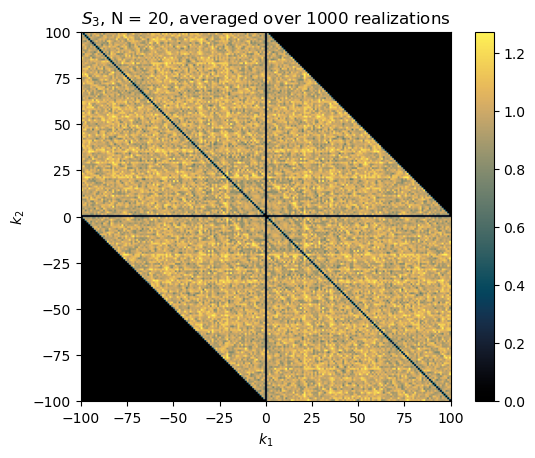

In [38]:
grid1 = np.arange(- Kint_1, Kint_1 + 1)

plt.figure()
plt.imshow(S3_avg, origin = 'lower', aspect='equal', cmap = cmr.eclipse, extent=[grid1[0], grid1[-1], grid1[0], grid1[-1]], 
           vmin = vmin_1a, vmax=vmax_1a)
plt.xlabel("$k_1$")
plt.ylabel("$k_2$")
plt.title("$S_3$" + ", N = "+ str(N_1) + 
          ", averaged over " + str(N_ens_1) + " realizations" )
plt.colorbar()

Text(0.5, 1.0, '$g_3$ for 1D poisson point pattern from IFFT of $S_3$')

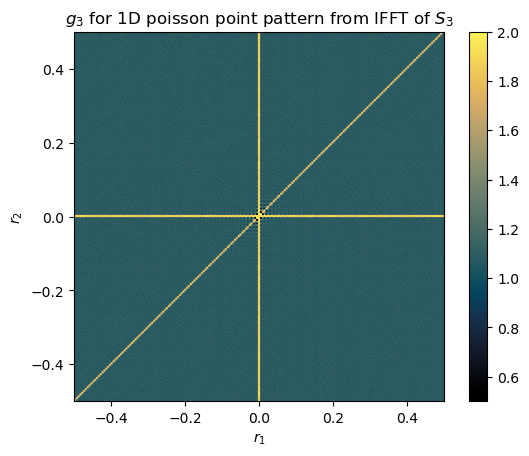

In [12]:
plt.figure()
grid_1 = np.linspace(-L1/2, L1/2, n_modes_1)
plt.imshow(g3_avg, origin = 'lower', aspect='equal', cmap = cmr.eclipse, 
           extent=[grid_1[0], grid_1[-1], grid_1[0], grid_1[-1]], vmin = 0.5, vmax = 2)
plt.colorbar()
plt.xlabel("$r_1$")
plt.ylabel("$r_2$")
plt.title("$g_3$ for 1D poisson point pattern from IFFT of $S_3$" )

3 points structure factor and pair correlation for hard rod

In [13]:
# Paramters
N2 = 300;
L2 = 1;
sigma = 10**(-1); 
n_modes_2 = 2001;
Kint_2 = 1000;

In [14]:
# Taking the middle point of each rod to be the new position
L_2_up = L2 + N2 * sigma; # updated L4
extension = np.arange(1, 2*(N2-1) + 2, 2) * (sigma/2);
phi = (N2*sigma)/L_2_up

In [15]:
phi

0.967741935483871

In [16]:
N_ens_2 = 5;

S3_2_ens = [];
g3_2_ens = [];

for i in range(N_ens_2):
    
    hard_rod_sample = L2 * np.random.rand(N2);
    hard_rod_sample = np.sort(hard_rod_sample);
    hard_rod_sample = hard_rod_sample + extension; # minus L/2
    hard_rod_sample = hard_rod_sample/L_2_up
    
    # Range is normalized to [0, 1]
    S3_2, g3_2 = structure_3points_1D(hard_rod_sample, 1, Kint_2);
    
    S3_2_ens.append(S3_2);
    g3_2_ens.append(g3_2);

In [17]:
S3_2_avg = np.real(np.mean(S3_2_ens, 0));
g3_2_avg = np.real(np.mean(g3_2_ens, 0));

In [18]:
grid2 = np.arange(- Kint_2, Kint_2 + 1);
grid_2 = np.linspace(-L2/2, L2/2, n_modes_2)

In [46]:
vmin_2a, vmax_2a = np.nanpercentile(np.real(S3_2_avg), [0.5, 99.5])

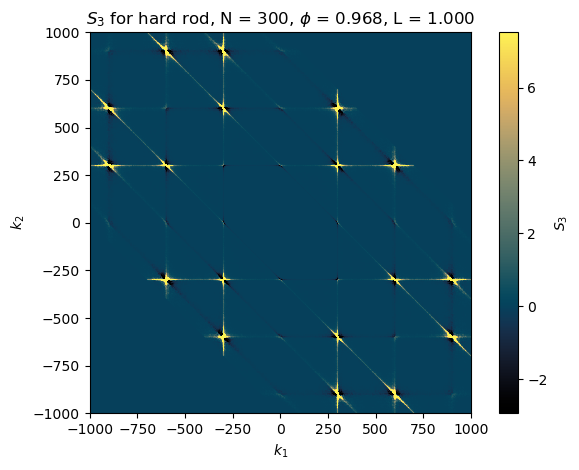

In [40]:
plt.figure()
plt.imshow(S3_2_avg, origin = 'lower', aspect='equal', cmap = cmr.eclipse, 
           extent=[grid2[0], grid2[-1], grid2[0], grid2[-1]], vmin = vmin_2a, vmax=vmax_2a)
'''
plt.imshow(S3_2_avg, origin = 'lower', aspect='equal', cmap = cmr.eclipse, 
           extent=[grid2[0], grid2[-1], grid2[0], grid2[-1]], norm = LogNorm(vmin=0.1, vmax=10))
'''

plt.xlabel("$k_1$");
plt.ylabel("$k_2$");

plt.title(rf"$S_3$ for hard rod, N = {N2}, "rf"$\phi$ = {phi:.3f}, "rf"L = {L2:.3f}" )
plt.colorbar(label = "$S_3$")
plt.xlim(-1000, 1000)
plt.ylim(-1000, 1000)
plt.tight_layout();

In [47]:
vmin_2b, vmax_2b = np.nanpercentile(np.real(g3_2_avg), [0.5, 99.5])

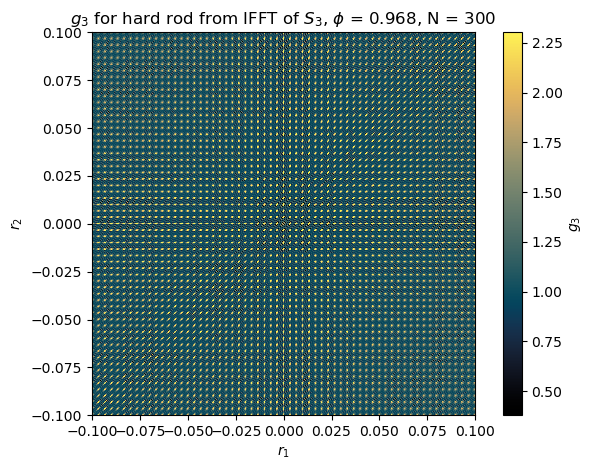

In [42]:
plt.figure()
plt.imshow(g3_2_avg, origin = 'lower', aspect='equal', cmap = cmr.eclipse, 
           extent=[grid_2[0], grid_2[-1], grid_2[0], grid_2[-1]], vmin = vmin_2b, vmax=vmax_2b)

plt.xlabel("$r_1$")
plt.ylabel("$r_2$")
plt.title(rf"$g_3$ for hard rod from IFFT of $S_3$, $\phi$ = {phi:.3f}, N = {N2}")
plt.colorbar(label = "$g_3$")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.tight_layout();

1d quasicrystal sequence

In [23]:
N_3 = 100;
tau = (1 + np.sqrt(5))/2;
beta = 0.1;
x_N = np.arange(1, N_3+1) + (1/tau) * np.floor(np.arange(1, N_3+1)/tau + beta);

n_modes_3 = 5001;
L3 = max(x_N) - min(x_N);
Kint_3 = 2500;

In [24]:
S_3_3, g_3_3 = structure_3points_1D(x_N, L3, Kint_3);

In [25]:
grid3 = np.arange(- Kint_3, Kint_3 + 1)
grid_3 = np.linspace(-L3/2, L3/2, n_modes_3)

In [48]:
vmin_3a, vmax_3a = np.nanpercentile(np.real(S_3_3), [0.5, 99.5])

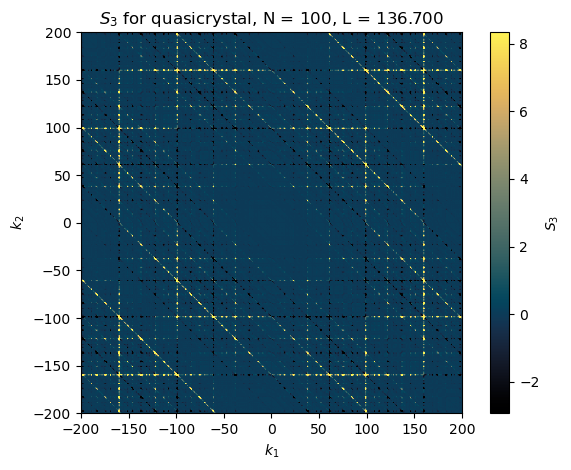

In [27]:
plt.figure()
plt.imshow(np.real(S_3_3), origin = 'lower', aspect='equal', cmap = cmr.eclipse, 
           extent=[grid3[0], grid3[-1], grid3[0], grid3[-1]], vmin = vmin_3a, vmax=vmax_3a)
plt.xlabel("$k_1$");
plt.ylabel("$k_2$");
plt.xlim(-200, 200)
plt.ylim(-200, 200)
plt.title(rf"$S_3$ for quasicrystal, N = {N_3}, L = {L3:.3f}")
plt.colorbar(label = "$S_3$")
plt.tight_layout();

In [49]:
vmin_3b, vmax_3b = np.nanpercentile(np.real(g_3_3), [0.5, 99.5])

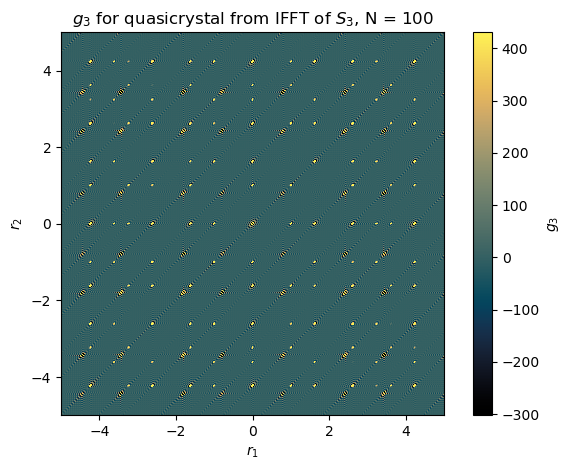

In [29]:
plt.figure()
plt.imshow(np.real(g_3_3), origin = 'lower', aspect='equal', cmap = cmr.eclipse, 
           extent=[grid_3[0], grid_3[-1], grid_3[0], grid_3[-1]], vmin = vmin_3b, vmax=vmax_3b)

plt.xlabel("$r_1$")
plt.ylabel("$r_2$")
plt.title(rf"$g_3$ for quasicrystal from IFFT of $S_3$, N = {N_3}")
plt.colorbar(label = "$g_3$")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.tight_layout();

periodic points

In [30]:
N_4 = 50;
L_4 = 1
sample_4 = np.linspace(0, L_4, N_4);
n_modes_4 = 4001;
Kint4 = 2000;

In [31]:
S3_4, g3_4 = structure_3points_1D(sample_4, 1, Kint4);

In [51]:
vmin_4a, vmax_4a = np.nanpercentile(np.real(S3_4), [0.5, 99.5])

In [33]:
grid4 = np.arange(- Kint4, Kint4 + 1)
grid_4 = np.linspace(-L_4/2, L_4/2, n_modes_4)

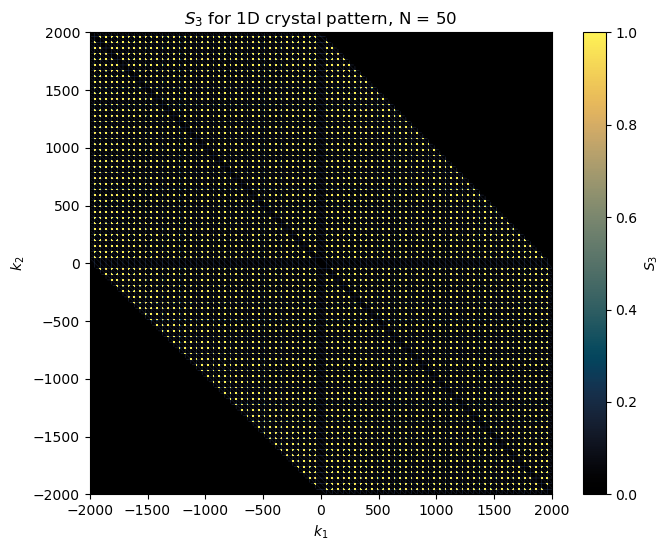

In [34]:
plt.figure(figsize = (8,6));

plt.imshow(np.real(S3_4), origin = 'lower', aspect='equal', cmap = cmr.eclipse, 
           extent=[grid4[0], grid4[-1], grid4[0], grid4[-1]], vmin = vmin_4a, vmax=vmax_4a)
plt.xlabel("$k_1$")
plt.ylabel("$k_2$")

plt.title(rf"$S_3$ for 1D crystal pattern" + ", N = "+ str(N_4))
plt.colorbar(label = "$S_3$")

In [50]:
vmin_4b, vmax_4b = np.nanpercentile(np.real(g3_4), [0.5, 99.5])

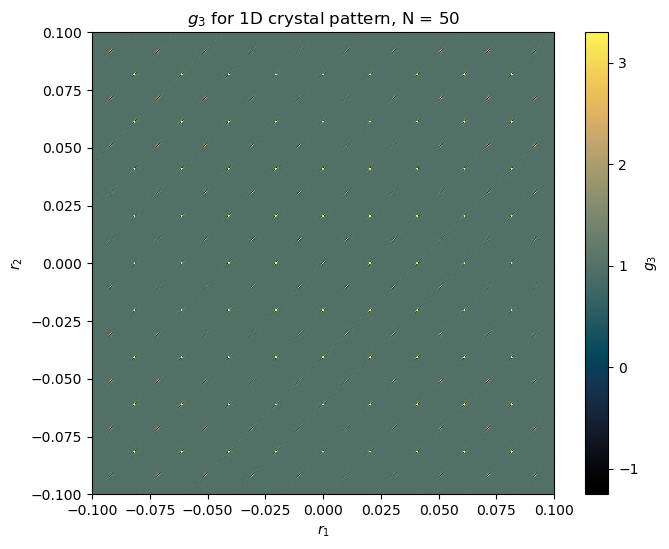

In [36]:
plt.figure(figsize = (8,6));
plt.imshow(np.real(g3_4), origin = 'lower', aspect='equal', cmap = cmr.eclipse, 
           extent=[grid_4[0], grid_4[-1], grid_4[0], grid_4[-1]], vmin = vmin_4b, vmax=vmax_4b);
plt.xlabel("$r_1$");
plt.ylabel("$r_2$");
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.title(rf"$g_3$ for 1D crystal pattern" + ", N = "+ str(N_4));
plt.colorbar(label = "$g_3$");